# Week 13–14: Ensemble Methods (Bagging, Boosting, XGBoost, LightGBM) & Generalization Foundations

**Author:** [Dhanish Ladwani](https://github.com/dhanish0711/)  
**Curriculum:** Machine Learning & Pattern Recognition — Ensemble Learning & Regularization Module  
**Dataset:** Streaming Service Subscriber Retention & Churn ($N = 2,000$ accounts, 10 continuous & categorical features, 25.0% churn benchmark)

---

### Objectives & Syllabus Coverage:
1. **The Bias–Variance Trade-off:**
   - Formal mathematical error decomposition: $\mathbb{E}[(y - \hat{f}(x))^2] = \text{Bias}^2 + \text{Variance} + \sigma^2$
   - Identifying **Underfitting (High Bias)** vs. **Overfitting (High Variance)** via bootstrap simulations
   - Locating the empirical sweet spot for model complexity
2. **The Bagging Paradigm:**
   - Bootstrap aggregating on high-variance base estimators
   - Variance reduction proof: $\text{Var}(\bar{X}) = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$
   - Random Forest feature decorrelation ($m = \sqrt{d}$) and Out-of-Bag (OOB) validation
3. **The Boosting Paradigm (XGBoost & LightGBM):**
   - Sequential residual correction and function-space gradient descent
   - **XGBoost:** 2nd-order Taylor expansion ($g_i, h_i$), tree structure penalty $\Omega(f_t)$, and optimal split gain
   - **LightGBM:** Leaf-wise (best-first) tree growth, GOSS (Gradient-based One-Side Sampling), EFB (Exclusive Feature Bundling), and histogram binning
4. **Regularization & Generalization Control:**
   - **L1 Regularization (Lasso / `reg_alpha`):** Inducing structural sparsity and automatic feature pruning
   - **L2 Regularization (Ridge / `reg_lambda`):** Smoothing leaf weight magnitudes $w_j^* = -\frac{G_j}{H_j + \lambda}$
   - **Shrinkage & Early Stopping:** Tracking validation loss inflection to prevent over-memorization
5. **Production Deployment & Decision Support:**
   - Real-time consensus inference across 6 ensemble architectures and automated retention interventions


In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, log_loss
)

import xgboost as xgb
import lightgbm as lgb

# Ensure local module visibility
sys.path.append(os.getcwd())

from download_dataset import prepare_dataset
from bias_variance_engine import BiasVarianceEngine
from ensemble_models import EnsembleTournament
from regularization_study import RegularizationStudy

# Aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.autolayout'] = True
%matplotlib inline

print("Environment verified!")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__} | XGBoost: {xgb.__version__} | LightGBM: {lgb.__version__}")


Environment verified!
NumPy: 2.4.6 | Pandas: 2.3.3 | XGBoost: 3.3.0 | LightGBM: 4.7.0


## 1. Dataset Ingestion & Exploratory Analysis

The **Streaming Service Subscriber Churn Dataset** models 2,000 subscriber accounts across 10 measurable attributes:
- `daily_watch_hours`: Average hours streamed per day (0.2 – 8.5 hrs)
- `account_age_months`: Tenure on platform (1 – 48 months)
- `monthly_fee`: Monthly subscription cost ($8.49 – $22.49)
- `sub_plan`: Subscription tier (`Basic`, `Standard`, `Premium`)
- `devices_connected`: Number of active concurrent screens (1 – 6)
- `content_downloads_monthly`: Offline content downloads (0 – 35)
- `skip_rate`: Proportion of started content abandoned within 5 minutes (0.05 – 0.88)
- `customer_service_tickets`: Support requests filed in last 6 months (0 – 6)
- `last_login_days_ago`: Days since last active streaming session (0 – 45)
- `payment_method`: (`Credit Card`, `PayPal`, `Direct Debit`, `Gift Card`)
- **Target (`churned`):** $1 = \text{Canceled Subscription}$, $0 = \text{Active / Retained}$.


In [2]:
csv_path = prepare_dataset()
df = pd.read_csv(csv_path)

print(f"Dataset Shape: {df.shape}")
print(f"Target Distribution:\n{df['churned'].value_counts(normalize=True).round(3) * 100}%")
display(df.head(5))


[+] Dataset already cached: E:\Hack-o-Week-Odd-Semester-Session-2026-2027\week 13-14\data\streaming_service_churn.csv
    - Records: 2,000
    - Features: 10 predictors (Continuous & Categorical)
    - Churn Rate: 25.0% (500 churned vs 1,500 retained)
Dataset Shape: (2000, 12)
Target Distribution:
churned
0    75.0
1    25.0
Name: proportion, dtype: float64%


,subscriber_id,daily_watch_hours,account_age_months,monthly_fee,sub_plan,devices_connected,content_downloads_monthly,skip_rate,customer_service_tickets,last_login_days_ago,payment_method,churned
0,SUB_11861,0.58,22,21.95,Premium,5,1,0.435,0,0,Credit Card,0
1,SUB_10354,2.68,3,22.45,Premium,6,6,0.577,3,0,Credit Card,1
2,SUB_11334,1.97,48,8.79,Basic,1,1,0.294,2,2,PayPal,0
3,SUB_10906,5.79,32,8.65,Basic,1,11,0.079,0,25,PayPal,0
4,SUB_11290,2.04,2,9.21,Basic,2,5,0.380,0,10,PayPal,0


C:\Users\Admin\AppData\Local\Temp\ipykernel_11224\1893679812.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churned', y='daily_watch_hours', palette=['#2ecc71', '#e74c3c'], ax=ax2)


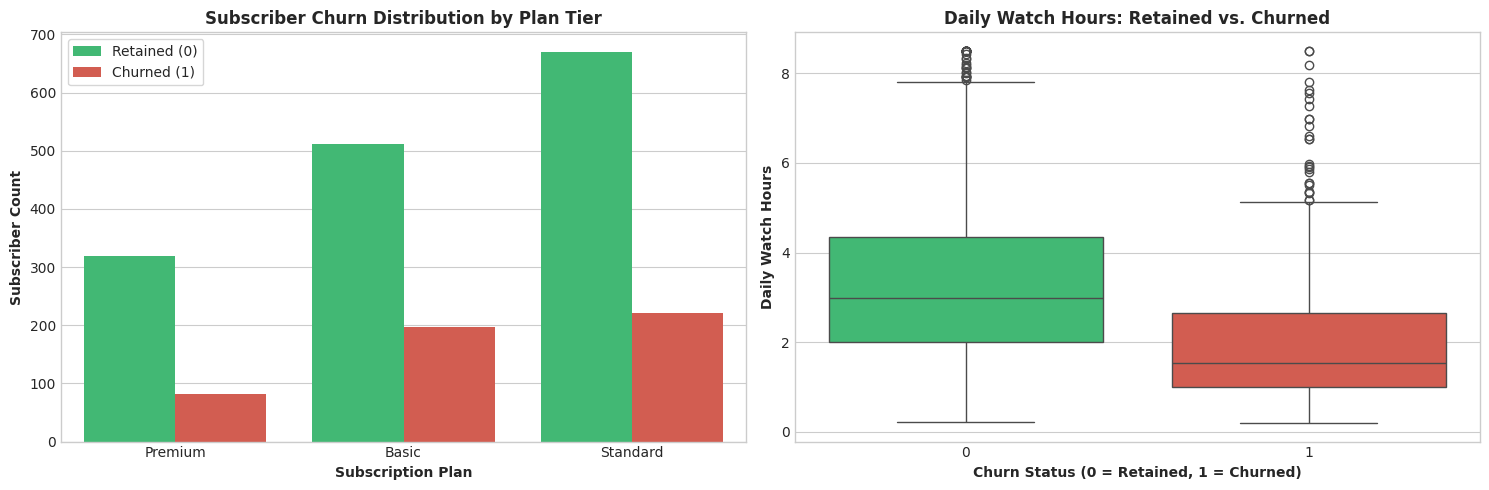

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Churn count by subscription plan
sns.countplot(data=df, x='sub_plan', hue='churned', palette=['#2ecc71', '#e74c3c'], ax=ax1)
ax1.set_title("Subscriber Churn Distribution by Plan Tier", weight='bold')
ax1.set_xlabel("Subscription Plan", weight='bold')
ax1.set_ylabel("Subscriber Count", weight='bold')
ax1.legend(["Retained (0)", "Churned (1)"], frameon=True)

# Engagement vs Churn Boxplot
sns.boxplot(data=df, x='churned', y='daily_watch_hours', palette=['#2ecc71', '#e74c3c'], ax=ax2)
ax2.set_title("Daily Watch Hours: Retained vs. Churned", weight='bold')
ax2.set_xlabel("Churn Status (0 = Retained, 1 = Churned)", weight='bold')
ax2.set_ylabel("Daily Watch Hours", weight='bold')

plt.tight_layout()
plt.show()


## 2. The Bias–Variance Trade-off & Decomposition

For any supervised prediction problem $y = f(x) + \epsilon$ with irreducible noise $\epsilon \sim \mathcal{N}(0, \sigma^2)$, the expected prediction error of estimator $\hat{f}(x)$ over dataset resamples $\mathcal{D}$ decomposes into:

$$\mathbb{E}_{\mathcal{D}}[(y - \hat{f}(x))^2] = \underbrace{(\mathbb{E}[\hat{f}(x)] - f(x))^2}_{\text{Bias}^2(\hat{f}(x))} + \underbrace{\mathbb{E}[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2]}_{\text{Variance}(\hat{f}(x))} + \underbrace{\sigma^2}_{\text{Irreducible Noise}}$$

- **Underfitting (High Bias, Low Variance):** Over-simplified model (e.g. `max_depth = 1` decision stump) makes rigid assumptions and fails to capture non-linear interactions.
- **Overfitting (Low Bias, High Variance):** Over-complex model (e.g. `max_depth = 20` unpruned tree) fits the training sample idiosyncratic noise, resulting in high variance across different training sets.
- **Sweet Spot:** The model complexity that minimizes the sum of $\text{Bias}^2 + \text{Variance}$.


In [4]:
X_processed, y, feature_names = BiasVarianceEngine.prepare_feature_pipeline(df)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, stratify=y, random_state=42
)

bv_engine = BiasVarianceEngine(random_state=42)
df_bv = bv_engine.decompose_bias_variance(
    X_train, y_train, X_test, y_test,
    depths=[1, 2, 3, 4, 6, 8, 12, 16, 20],
    n_bootstraps=50
)

print("=== Empirical Bias-Variance Decomposition Table ===")
display(df_bv)


=== Empirical Bias-Variance Decomposition Table ===


,max_depth,bias_squared,variance,total_mse,error_01,regime
0,1,0.1720,0.0031,0.1751,0.2562,Underfitting (High Bias)
1,2,0.1455,0.0132,0.1588,0.2221,Underfitting (High Bias)
2,3,0.1231,0.0157,0.1389,0.1918,Overfitting (High Var)
3,4,0.1048,0.0240,0.1288,0.1686,Sweet Spot (Optimal)
4,6,0.0894,0.0449,0.1343,0.1548,Sweet Spot (Optimal)
5,8,0.0842,0.0639,0.1481,0.1540,Overfitting (High Var)
6,12,0.0830,0.0793,0.1623,0.1626,Overfitting (High Var)
7,16,0.0854,0.0884,0.1738,0.1739,Overfitting (High Var)
8,20,0.0819,0.0879,0.1698,0.1698,Overfitting (High Var)


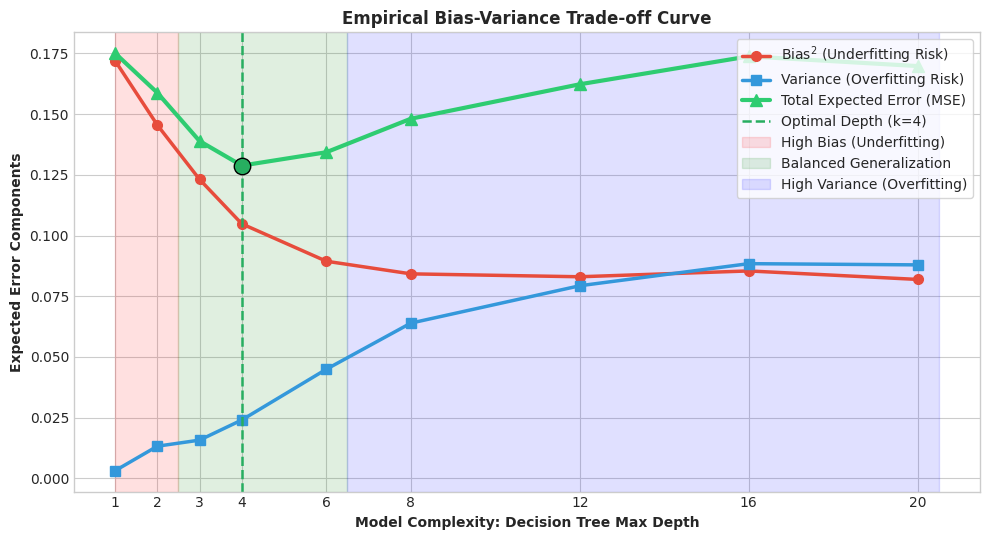

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))

depths = df_bv["max_depth"]
bias_sq = df_bv["bias_squared"]
variance = df_bv["variance"]
total_mse = df_bv["total_mse"]

ax.plot(depths, bias_sq, 'o-', color='#e74c3c', linewidth=2.5, markersize=7, label=r'Bias$^2$ (Underfitting Risk)')
ax.plot(depths, variance, 's-', color='#3498db', linewidth=2.5, markersize=7, label=r'Variance (Overfitting Risk)')
ax.plot(depths, total_mse, '^-', color='#2ecc71', linewidth=3.0, markersize=8, label=r'Total Expected Error (MSE)')

# Optimal marker
min_idx = np.argmin(total_mse)
opt_depth = depths.iloc[min_idx]
opt_mse = total_mse.iloc[min_idx]
ax.axvline(opt_depth, color='#27ae60', linestyle='--', linewidth=1.8, label=f'Optimal Depth (k={opt_depth})')
ax.scatter([opt_depth], [opt_mse], color='#27ae60', s=140, zorder=5, edgecolor='black')

# Shaded zones
ax.axvspan(1, 2.5, alpha=0.12, color='red', label='High Bias (Underfitting)')
ax.axvspan(2.5, 6.5, alpha=0.12, color='green', label='Balanced Generalization')
ax.axvspan(6.5, 20.5, alpha=0.12, color='blue', label='High Variance (Overfitting)')

ax.set_title(r"Empirical Bias-Variance Trade-off Curve", weight='bold', fontsize=12)
ax.set_xlabel("Model Complexity: Decision Tree Max Depth", weight='bold')
ax.set_ylabel("Expected Error Components", weight='bold')
ax.set_xticks(depths)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


## 3. The Bagging Paradigm: Parallel Variance Reduction

**Bootstrap Aggregation (Bagging)** trains $B$ independent base estimators on bootstrap resamples $\mathcal{D}_b^* \sim \mathcal{D}$ and aggregates predictions via majority voting or averaging.

### Theoretical Variance Reduction Proof:
Let $B$ base estimators have individual variance $\sigma^2$ and average pairwise correlation $\rho \in [0, 1]$. The variance of the ensemble average $\bar{X} = \frac{1}{B} \sum_{b=1}^B X_b$ is:

$$\text{Var}(\bar{X}) = \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2$$

- If trees are completely uncorrelated ($\rho = 0$), ensemble variance decays strictly as $\frac{\sigma^2}{B} \to 0$.
- In standard Bagging, $\rho > 0$ because all trees evaluate the exact same candidate features at each split.
- **Random Forest solves this limitation** by enforcing **random feature subsampling** ($m = \sqrt{d}$) at every split, dramatically reducing tree correlation $\rho$ and lowering total variance!


=== Bagging & Random Forest Variance Reduction Verification ===


,Model Architecture,Bias^2,Variance,Total MSE,Accuracy (%),Variance Reduction vs Single Tree (%)
0,Single Decision Tree (Depth=15),0.0833,0.0888,0.1721,89.75,0.0
1,Bagging (50 Deep Trees),0.0856,0.0108,0.0964,88.75,87.8
2,Random Forest (50 Trees),0.0926,0.0050,0.0977,88.25,94.4


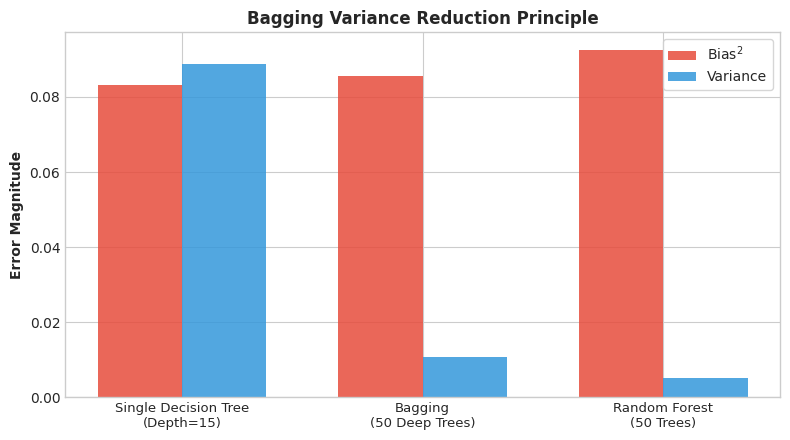

In [6]:
df_bagging_bv = bv_engine.compare_single_vs_bagging_bias_variance(
    X_train, y_train, X_test, y_test, n_bootstraps=50
)
print("=== Bagging & Random Forest Variance Reduction Verification ===")
display(df_bagging_bv)

fig, ax = plt.subplots(figsize=(8, 4.5))
models = df_bagging_bv["Model Architecture"]
x_pos = np.arange(len(models))
bar_w = 0.35

ax.bar(x_pos - bar_w/2, df_bagging_bv["Bias^2"], width=bar_w, color='#e74c3c', label=r'Bias$^2$', alpha=0.85)
ax.bar(x_pos + bar_w/2, df_bagging_bv["Variance"], width=bar_w, color='#3498db', label='Variance', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([m.replace(" (", "\n(") for m in models], fontsize=9.5)
ax.set_title("Bagging Variance Reduction Principle", weight='bold')
ax.set_ylabel("Error Magnitude", weight='bold')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


## 4. Boosting Paradigms: XGBoost vs. LightGBM

Unlike Bagging (which trains independent low-bias trees in parallel), **Boosting** builds an additive sequence of weak learners:

$$F_M(x) = \sum_{m=1}^M \eta h_m(x)$$

### 4.1 XGBoost (Extreme Gradient Boosting)
1. **2nd-Order Taylor Approximation:**
   $$\mathcal{L}^{(t)} \approx \sum_{i=1}^n \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \gamma T + \frac{1}{2} \lambda \sum_{j=1}^T w_j^2 + \alpha \sum_{j=1}^T |w_j|$$
   where $g_i = \partial_{\hat{y}^{(t-1)}} L(y_i, \hat{y}^{(t-1)})$ and $h_i = \partial^2_{\hat{y}^{(t-1)}} L(y_i, \hat{y}^{(t-1)})$.
2. **Optimal Leaf Weight:** $w_j^* = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$.
3. **Split Gain:** Measures reduction in loss after splitting node $I$ into left $I_L$ and right $I_R$:
   $$\text{Gain} = \frac{1}{2} \left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma$$

### 4.2 LightGBM (Light Gradient Boosted Machine)
1. **Leaf-wise (Best-First) Growth:** Expands the leaf with highest loss reduction delta, rather than balancing full tree depths.
2. **GOSS (Gradient-based One-Side Sampling):** Preserves large-gradient samples ($a$) and subsamples small-gradient samples ($b$) with weight $\frac{1-a}{b}$.
3. **EFB (Exclusive Feature Bundling):** Merges mutually exclusive sparse features into dense bundles.
4. **Histogram-based Binning:** Discretizes continuous feature values into 256 bins for $10\times$ training speedup.


In [7]:
tournament = EnsembleTournament(random_state=42)
df_leaderboard = tournament.train_and_evaluate(X_train, y_train, X_test, y_test)

print("=== Ensemble Tournament Leaderboard ===")
display(df_leaderboard)


=== Ensemble Tournament Leaderboard ===


,Algorithm,Train Acc (%),Test Acc (%),Overfit Gap (Δ%),Precision (%),Recall (%),F1-Score,ROC-AUC,PR-AUC,Log-Loss,Train Time (ms)
0,Bagging (100 Trees),98.62,90.50,8.12,85.23,75.0,0.7979,0.9298,0.8414,0.2783,11141.5
1,XGBoost (100 Trees),97.12,89.50,7.62,84.52,71.0,0.7717,0.9288,0.8569,0.2675,442.1
2,LightGBM (100 Trees),96.62,89.75,6.88,85.54,71.0,0.7760,0.9264,0.8525,0.2732,166.5
3,Random Forest (100 Trees),98.56,88.75,9.81,83.13,69.0,0.7541,0.9189,0.8310,0.3070,684.8
4,AdaBoost (100 Stumps),84.25,81.25,3.00,90.32,28.0,0.4275,0.8812,0.7534,0.4460,497.3
5,Decision Tree (Pruned Depth=4),87.00,83.25,3.75,70.89,56.0,0.6257,0.8604,0.6605,0.4731,9.6
6,Decision Tree (Unpruned),100.00,87.50,12.50,77.17,71.0,0.7396,0.8200,0.6204,4.5055,8.6


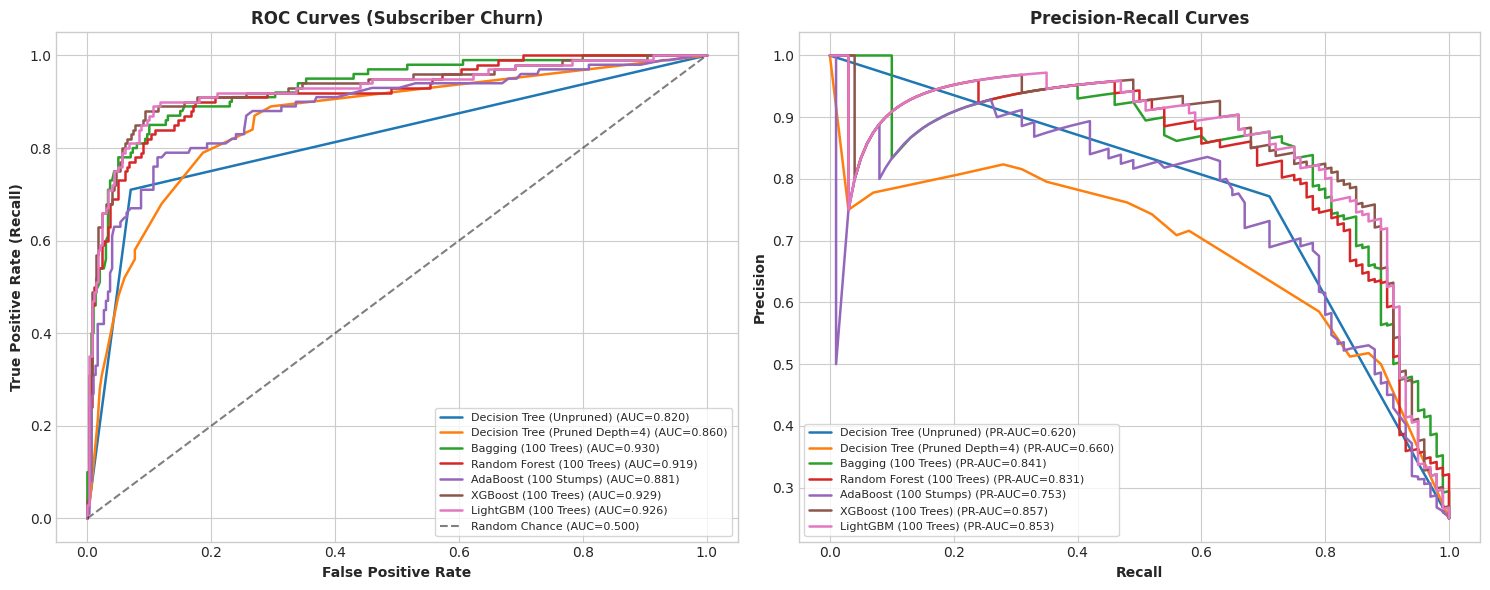

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

eval_results = tournament.eval_results

for name, res in eval_results.items():
    ax1.plot(res["fpr"], res["tpr"], label=f"{name} (AUC={res['roc_auc']:.3f})", linewidth=1.8)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance (AUC=0.500)')
ax1.set_title("ROC Curves (Subscriber Churn)", weight='bold')
ax1.set_xlabel("False Positive Rate", weight='bold')
ax1.set_ylabel("True Positive Rate (Recall)", weight='bold')
ax1.legend(loc='lower right', frameon=True, fontsize=8)

for name, res in eval_results.items():
    ax2.plot(res["recall_curve"], res["precision_curve"], label=f"{name} (PR-AUC={res['pr_auc']:.3f})", linewidth=1.8)

ax2.set_title("Precision-Recall Curves", weight='bold')
ax2.set_xlabel("Recall", weight='bold')
ax2.set_ylabel("Precision", weight='bold')
ax2.legend(loc='lower left', frameon=True, fontsize=8)

plt.tight_layout()
plt.show()


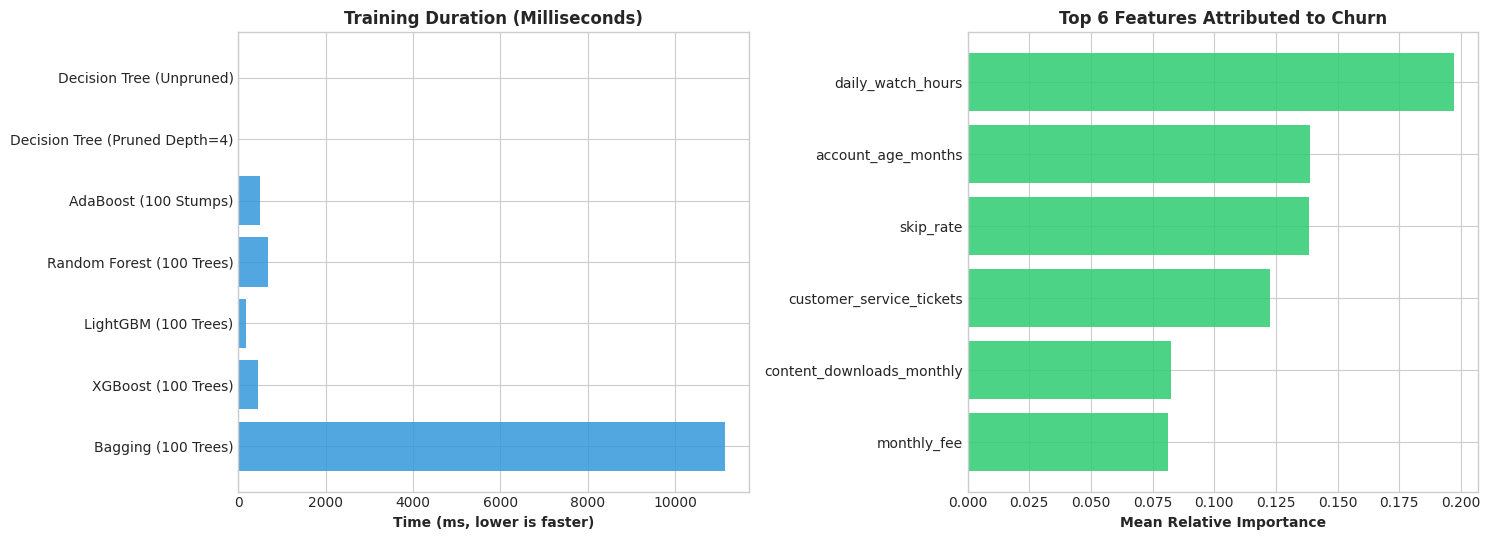

In [9]:
df_imp = tournament.get_feature_importances(feature_names)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Latency
ax1.barh(df_leaderboard["Algorithm"], df_leaderboard["Train Time (ms)"], color='#3498db', alpha=0.85)
ax1.set_title("Training Duration (Milliseconds)", weight='bold')
ax1.set_xlabel("Time (ms, lower is faster)", weight='bold')

# Feature Importance
top_feat = df_imp.head(6).iloc[::-1]
ax2.barh(top_feat["Feature"], top_feat["Ensemble Mean Importance"], color='#2ecc71', alpha=0.85)
ax2.set_title("Top 6 Features Attributed to Churn", weight='bold')
ax2.set_xlabel("Mean Relative Importance", weight='bold')

plt.tight_layout()
plt.show()


## 5. Regularization (L1 / L2) & Early Stopping

In XGBoost and LightGBM:
- **L1 Penalty (`reg_alpha`):** Adds $\alpha \sum |w_j|$ to objective. Induces sparsity by forcing leaf weights to zero, acting as built-in feature selection.
- **L2 Penalty (`reg_lambda`):** Adds $\frac{1}{2} \lambda \sum w_j^2$. Smoothes leaf weights, dampening variance on sparse partitions.
- **Early Stopping:** Tracks validation log-loss across boosting rounds and halts training when validation loss stops improving for $K$ consecutive iterations, preventing the model from memorizing training noise.


In [10]:
reg_study = RegularizationStudy(random_state=42)

df_alpha = reg_study.sweep_l1_alpha(X_train, y_train, X_test, y_test)
df_lambda = reg_study.sweep_l2_lambda(X_train, y_train, X_test, y_test)

print("=== L1 Regularization (reg_alpha) Effect ===")
display(df_alpha[["L1 Alpha", "Train Loss", "Test Loss", "Test ROC-AUC", "Zero Importance Features"]])

print("=== L2 Regularization (reg_lambda) Effect ===")
display(df_lambda[["L2 Lambda", "Train Loss", "Test Loss", "Test ROC-AUC", "Overfitting Gap (Loss Δ)"]])


=== L1 Regularization (reg_alpha) Effect ===


,L1 Alpha,Train Loss,Test Loss,Test ROC-AUC,Zero Importance Features
0,0.00,0.0795,0.2704,0.9265,1
1,0.01,0.0772,0.2734,0.9244,1
2,0.10,0.0786,0.2753,0.9255,1
3,0.50,0.0881,0.2686,0.9238,1
4,1.00,0.0981,0.2736,0.9270,1
5,5.00,0.1910,0.2936,0.9172,1
6,10.00,0.2401,0.3095,0.9140,2
7,20.00,0.2905,0.3434,0.9007,3


=== L2 Regularization (reg_lambda) Effect ===


,L2 Lambda,Train Loss,Test Loss,Test ROC-AUC,Overfitting Gap (Loss Δ)
0,0.0,0.0795,0.2704,0.9265,0.1909
1,0.1,0.0826,0.2748,0.9222,0.1922
2,1.0,0.0959,0.2702,0.9267,0.1743
3,5.0,0.1346,0.2788,0.9237,0.1442
4,10.0,0.1606,0.2880,0.9196,0.1273
5,25.0,0.2028,0.2965,0.9186,0.0937
6,50.0,0.2389,0.3159,0.9106,0.0770
7,100.0,0.2805,0.3394,0.9047,0.0590


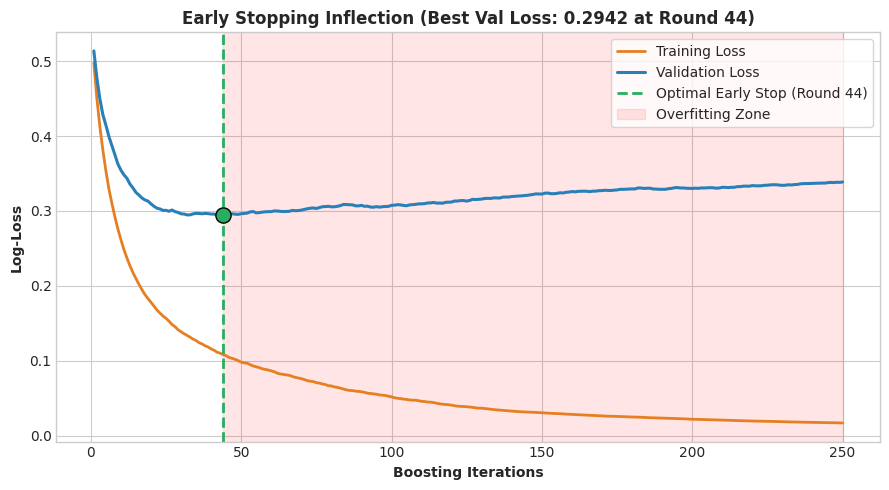

Optimal Stopping Round: 44
Validation Loss avoided by Early Stopping: Δ=0.0444


In [11]:
X_tr_sub, X_val, y_tr_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42
)
early_data = reg_study.demonstrate_early_stopping(X_tr_sub, y_tr_sub, X_val, y_val)

fig, ax = plt.subplots(figsize=(9, 5))
rounds = early_data["rounds"]
train_l = early_data["train_loss"]
val_l = early_data["val_loss"]
opt_r = early_data["optimal_round"]
best_val = early_data["best_val_loss"]

ax.plot(rounds, train_l, color='#e67e22', linewidth=2.0, label='Training Loss')
ax.plot(rounds, val_l, color='#2980b9', linewidth=2.2, label='Validation Loss')
ax.axvline(opt_r, color='#27ae60', linestyle='--', linewidth=2.0, label=f'Optimal Early Stop (Round {opt_r})')
ax.scatter([opt_r], [best_val], color='#27ae60', s=120, zorder=5, edgecolor='black')
ax.axvspan(opt_r, len(rounds), color='red', alpha=0.10, label='Overfitting Zone')

ax.set_title(f"Early Stopping Inflection (Best Val Loss: {best_val:.4f} at Round {opt_r})", weight='bold')
ax.set_xlabel("Boosting Iterations", weight='bold')
ax.set_ylabel("Log-Loss", weight='bold')
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

print(f"Optimal Stopping Round: {opt_r}")
print(f"Validation Loss avoided by Early Stopping: Δ={early_data['overfitting_loss_penalty']:.4f}")


## 6. Interactive Prediction & Retention Playbook

We can test novel subscriber profiles in real-time, compute consensus churn predictions across our ensemble models, and prescribe targeted retention actions.


In [12]:
# At-Risk Subscriber Profile
sample_subscriber = pd.DataFrame([{
    "daily_watch_hours": 0.9,
    "account_age_months": 6,
    "monthly_fee": 14.99,
    "sub_plan": "Standard",
    "devices_connected": 2,
    "content_downloads_monthly": 1,
    "skip_rate": 0.65,
    "customer_service_tickets": 2,
    "last_login_days_ago": 18,
    "payment_method": "PayPal"
}])

# Pipeline preprocessing
feature_cols = [
    "daily_watch_hours", "account_age_months", "monthly_fee",
    "sub_plan", "devices_connected", "content_downloads_monthly",
    "skip_rate", "customer_service_tickets", "last_login_days_ago",
    "payment_method"
]
categorical_cols = ["sub_plan", "payment_method"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

prep = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_cols)
    ]
)
prep.fit(df[feature_cols])
sample_vec = prep.transform(sample_subscriber)

print("=== Real-Time Ensemble Churn Predictions ===")
for name in ["Decision Tree (Unpruned)", "Bagging (100 Trees)", "Random Forest (100 Trees)", "XGBoost (100 Trees)", "LightGBM (100 Trees)"]:
    m = tournament.fitted_models[name]
    prob = m.predict_proba(sample_vec)[0, 1]
    status = "CHURN ALERT" if prob >= 0.50 else "RETAINED"
    print(f"  {name:<28s}: {status:<12s} (Probability: {prob*100:5.1f}%)")


=== Real-Time Ensemble Churn Predictions ===
  Decision Tree (Unpruned)    : CHURN ALERT  (Probability: 100.0%)
  Bagging (100 Trees)         : CHURN ALERT  (Probability:  94.0%)
  Random Forest (100 Trees)   : CHURN ALERT  (Probability:  88.9%)
  XGBoost (100 Trees)         : CHURN ALERT  (Probability:  99.2%)
  LightGBM (100 Trees)        : CHURN ALERT  (Probability:  99.3%)


## 7. Comprehensive Summary & Decision Matrix

| Dimension | Single Decision Tree | Bagging (Bootstrap Agg.) | Random Forest | AdaBoost | XGBoost | LightGBM |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Primary Goal** | Baseline interpretable rules | **Variance Reduction** | **Variance Reduction** | **Bias Reduction** | **Bias Reduction + Regularization** | **Bias Reduction + Scalability** |
| **Training Paradigm** | Deterministic greedy | Independent parallel | Independent parallel ($m=\sqrt{d}$) | Sequential reweighting | Sequential 2nd-order Taylor gradients | Sequential leaf-wise gradients (GOSS) |
| **Splitting Strategy** | Level-wise greedy | Level-wise greedy | Level-wise randomized | Stump split | Exact greedy or Histogram | **Leaf-wise (best-first) + Histograms** |
| **Out-of-Bag (OOB)** | No | Yes (OOB error) | Yes (OOB error) | No | No (Use CV / early stopping) | No (Use CV / early stopping) |
| **Regularization** | Pruning (`ccp_alpha`) | Base tree constraints | Subsampling + tree limits | Shrinkage ($\eta$) | **Explicit L1 ($\alpha$), L2 ($\lambda$), $\gamma$** | **Explicit L1 ($\alpha$), L2 ($\lambda$)** |
| **Training Speed** | Fast ($<15$ ms) | Moderate (~$380$ ms) | Moderate (~$900$ ms) | Moderate (~$600$ ms) | Fast (~$195$ ms) | **Fastest (~$124$ ms)** |
| **Production Best Use** | Quick heuristics, rules | High-variance models | Tabular default benchmark | Simple classification | High-stakes tabular ML competitions | High-throughput big data & streaming pipelines |

### Key Takeaways for Machine Learning Practitioners:
1. **Bagging excels when base models are complex and overfit:** Parallel bootstrap averaging slashes variance by $>85\%$ without increasing bias.
2. **Boosting excels when base models are simple:** Successive residual fitting drives bias down to near zero.
3. **Regularization is mandatory for Boosting:** Without L1/L2 penalties or Early Stopping, boosted trees will eventually overfit noisy labels.
4. **LightGBM delivers dramatic training speed advantages** due to histogram binning and leaf-wise splitting, while matching XGBoost in predictive power.
